In [59]:
import os

import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt, rcParams, colors, cm
import synapseclient
from scipy import stats
import numpy as np

rcParams["font.family"] = "Arial"
rcParams["font.size"] = 5

In [2]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse ID for the combined data table
COMBINED_TABLE_SYN_ID = "syn74775996"

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "cell_types"
)

In [ ]:
# ensure figure directory exists
os.makedirs(FIGURE_DIR, exist_ok=True)

In [ ]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.13.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.13.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



In [50]:
gene_sets = {
    "normal_hsc_prog": [
        "SPINK2", "ZFAS1", "NRIP1", "GAS5", "JUN", "MEIS1", "HLF", "EGR1", "CRHBP", "NPR3", 
        "FAM30A", "MMRN1", "MSI2", "ANGPT1", "EIF4A2", "TPT1", "COMMD6", "EEF1A1", "SNORD13", "PBX1",
        "FAU", "FOS", "PHLDB2", "MSRB3", "GUCY1A3", "C6orf48", "GBP4", "PCDH9", "SNHG6", "RACK1", 
        "ADGRG6", "PREX2", "PRKG2", "HINT1", "RNA5-8S", "NFKBIZ", "MYCT1", "TUBA1A", "CD34", "ZBTB20", 
        "TFPI", "SNHG8", "AVP", "CEP70", "H3F3B", "RNU4-2", "HIST1H2BG", "HOPX", "TSC22D1", "LRRC70", 
    ],
    "normal_gmp": [
        "CPA3", "PRSS57", "ELANE", "SUCNR1", "CALR", "PRTN3", "AZU1", "CST7", "NUCB2", "CTSG", 
        "EREG", "IGFBP2", "TRH", "FAM46A", "SERPINB1", "C1QTNF4", "VAT1", "CEACAM6", "CAT", "TSPOAP1", 
        "SNHG25", "MPO", "CLEC11A", "SLC2A5", "PRRT4", "ERLIN1", "PCOLCE2", "NCOA4", "CD38", "SPARC", 
        "VAMP8", "OSTC", "LINC01268", "ANKRD18A", "HYOU1", "SLPI", "MANF", "CLDN10", "DPM3", "CHRNB1",
        "FDX1", "HSPA5", "CEBPA", "TMEM258", "CDCA7", "RNASEH2C", "HGF", "LINC01835", "BEND6", "FAM201A",
    ],
    "normal_myeloid": [
        "VCAN", "S100A9", "S100A8", "MNDA", "FCN1", "LYZ", "THBS1", "CSTA", "SAMSN1", "FGL2", 
        "TYROBP", "IFI30", "PLBD1", "S100A12", "ANXA2", "S100A10", "PSAP", "FCER1G", "SAMHD1", "LGALS1", 
        "COTL1", "CTSH", "CTSS", "S100A6", "ITGB2", "FPR1", "MEGF9", "CD14", "MS4A6A", "FTL", 
        "KCTD12", "S100A4", "IGSF6", "NCF2", "CLEC7A", "S100A11", "CST3", "CEBPD", "ARPC1B", "CD68", 
        "IFNGR1", "PTPRE", "RAB31", "GPR183", "NAMPT", "TSPO", "CD86", "IRS2", "LRRK2", "GLIPR2",
    ],
    "tumor_hsc_prog_like": [
        "SPINK2", "ANGPT1", "GUCY1A3", "FAM30A", "MMRN1", "TPT1", "GAS5", "RAB27B", "TPM4", "MSI2", 
        "GCSAML", "SOCS2", "EEF1A1", "NRIP1", "HOPX", "CD34", "TFPI", "TPSD1", "PDZRN4", "PCNP", 
        "PTPRCAP", "FLT3", "SMIM24", "SELENOP", "DAPK1", "SMYD3", "ADGRG6", "PIM1", "MECOM", "CEP70", 
        "XIRP2", "SPAG6", "TAPT1-AS1", "GNA15", "DSE", "TPSAB1", "TPSB2", "H2AFY", "SCHIP1", "LINC02470", 
        "NPR3", "KMT2A", "CD200", "MACF1", "GBP4", "ABCC1", "PROM1", "TMEM70", "FAM110A", "TMEM123",
    ],
    "tumor_gmp_like": [
        "PRTN3", "MPO", "CALR", "CLEC5A", "ELANE", "POU4F1", "TRH", "TSPOAP1", "CEBPE", "LINC01835", 
        "NUCB2", "CSF3R", "RUNX1T1", "CD38", "PLPPR3", "IGFBP2", "PRRT4", "SNHG5", "FABP5", "LOC100419170", 
        "CLEC11A", "SERPINB1", "AZU1", "FBN2", "HNRNPDL", "HSPB1", "RNA5-8S", "THSD7A", "C12orf57", "FGFR1", 
        "LPO", "MGST1", "C1QTNF4", "HMGN1", "SIPA1L2", "DDOST", "PTGIR", "GATM", "VAMP8", "FAM46A", 
        "VAMP5", "STAR", "ANKRD18A", "TM7SF3", "CCND1", "ROBO1", "GFI1", "DEFA4", "CERS6", "PTMA",
    ],
    "tumor_myeloid_like": [
        "LYZ", "S100A9", "S100A8", "VCAN", "MNDA", "CSTA", "SRGN", "FCN1", "FTL", "MS4A6A", 
        "PSAP", "IFI30", "ANXA2", "FGL2", "S100A10", "LGALS3", "CTSS", "ANXA1", "ANXA5", "AIF1", 
        "NCF2", "LYST", "FCER1G", "CD68", "TNFSF13B", "VIM", "IRS2", "GRN", "TNFAIP2", "MCL1", 
        "MS4A7", "CLEC12A", "S100A12", "MEGF9", "CFD", "S100A6", "TLR4", "KLF4", "SERPINA1", "MAFB", 
        "CTSD", "TMEM170B", "NAMPT", "C1orf162", "S100A11", "CEBPD", "ADA2", "CD14", "IL17RA", "DUSP1",
    ],
    "tumor_hsc_like": [
        "NPTX2", "H1F0", "EMP1", "MEIS1", "CALCRL", "TPSD1", "TPT1", "CRHBP", "CLNK", "TSC22D1", 
        "DST", "NRIP1", "ABCB1", "GABRA4", "ZBTB20", "ABCA9", "TPSB2", "KMT2A", "FAM30A", "MEF2C", 
        "TMEM74", "PDZRN4", "ST3GAL1", "XIRP2", "RBPMS", "TMEM25", "C20orf203", "GNG11", "SLC6A13", "HOPX", 
        "CMTM2", "HIST1H2BK", "NPDC1", "SCRN1", "MECOM", "CXCL2", "CCS", "FAM74A4", "UMODL1-AS1", "CCDC18-AS1", 
        "TTLL10", "CFAP61", "PLCB4", "SPON1", "LINC01770", "CACNB4", "CCDC144NL-AS1", "RNF217", "ZPBP", "MPPED2",
    ],
    "tumor_prog_like": [
        "CDK6", "HSP90AB1", "SPINK2", "EEF1B2", "PCNP", "TAPT1-AS1", "HINT1", "LRRC75A-AS1", "DSE", "PEBP1", 
        "LOC107984974", "H2AFY", "EEF1A1", "SMIM24", "PSME1", "SOX4", "LINC01623", "EEF1G", "EBPL", "EIF4B", 
        "PARP1", "MEST", "TMEM70", "TFDP2", "ATP5G2", "NAP1L1", "MSI2", "TPM4", "SPN", "SELL", 
        "RACK1", "CTSC", "PRDX6", "EGFL7", "SNHG6", "NOP53", "MRPL57", "SELENOP", "CCDC152", "SRSF6", 
        "SNHG8", "B4GALT6", "HNRNPA1", "KIF2A", "HSH2D", "PTPRCAP", "NACA2", "PDLIM1", "CPA3", "GNPTAB",
    ],
    "tumor_promono_like": [
        "DEFB1", "RNASE2", "MS4A3", "SERPINB10", "SESN3", "ZFR", "MRPL33", "CTSG", "SLC44A1", "SLPI", 
        "FUT4", "SRGN", "CD70", "PRLR", "PLD3", "LPL", "RETN", "TP53INP2", "HSPA5", "RNASE3", 
        "CCL23", "EMB", "ATP8B4", "CLU", "FAM107B", "KBTBD11", "CSTA", "ANKRD28", "PIWIL4", "RNVU1-6", 
        "F13A1", "PROK2", "IL31RA", "PLAC8", "ELF1", "EP400NL", "EAF2", "RFX8", "PTGFR", "JUN", 
        "FRMD3", "HOXB-AS3", "PHACTR3", "AK2", "ECRP", "DDIT3", "RFLNB", "FEZ1", "SERPINB2", "CDKN2A", 
    ],
    "tumor_mono_like": [
        "FCN1", "S100A12", "MAFB", "VCAN", "S100A9", "PLBD1", "SERPINA1", "BCL2A1", "THBS1", "PSAP", 
        "S100A8", "FPR1", "C5AR1", "CD14", "NAMPT", "VNN2", "CTSS", "DUSP1", "CEBPB", "CR1", 
        "NFKBIA", "SLC11A1", "LILRB3", "BCL6", "CYP1B1", "TNFAIP2", "MS4A10", "AQP9", "TLR4", "APOBEC3A", 
        "LRRK2", "CD163", "LRP1", "S100A10", "CD68", "MEGF9", "NCF2", "LOC643802", "IFNGR1", "FTL", 
        "SLC24A4", "CD300E", "CXCL8", "CLEC7A", "NEAT1", "CLEC4E", "CRISPLD2", "MEFV", "ACSL1", "NCF1", 
    ],
    "tumor_cdc_like": [
        "MRC1", "HLA-DRB5", "CST3", "SAMHD1", "NAPSB", "FCER1A", "HLA-DRB1", "JAML", "PKIB", "HLA-DRA", 
        "HLA-DRB6", "CPVL", "HLA-DPB1", "HLA-DQA1", "HLA-DPA1", "CLEC4A", "TMSB10", "CAP1", "HLA-DQB1", "CRIP1", 
        "CLEC10A", "GPX1", "ITGB7", "HLA-DQB2", "DBI", "FTH1P3", "ACTB", "HLA-DQA2", "S100B", "ALDH2", 
        "GABARAP", "LY86", "IGSF6", "HLA-DPB2", "CD74", "PAK1", "LGALS2", "CSF1R", "PALLD", "CCR2", 
        "GPR183", "GRB2", "EPS8", "COTL1", "DHRS9", "HLA-DMB", "HLA-DMA", "PYCARD", "LOC644936", "SH3BGRL3", 
    ]
}

In [47]:
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    b_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    b_mut_cols = mutf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:
    w_wt_cols = wtf.read().split("\n")
with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:
    w_mut_cols = mutf.read().split("\n")

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/928073276.py:1: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/928073276.py:3: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/928073276.py:5: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_wt-cols.txt"]).path, "r") as wtf:



[syn74776660:W_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/353/174033353/W_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/928073276.py:7: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT_mut-cols.txt"]).path, "r") as mutf:



[syn74776659:W_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/684/172720684/W_NPM1-WT_mut-cols.txt, skipping download.


In [62]:
def v2c(v): 
    return colors.to_hex(
        cm.ScalarMappable(
            norm=colors.Normalize(vmin=-1, vmax=1), 
            cmap="coolwarm"
        ).to_rgba(v)  # type: ignore
    )

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_hsc_prog
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


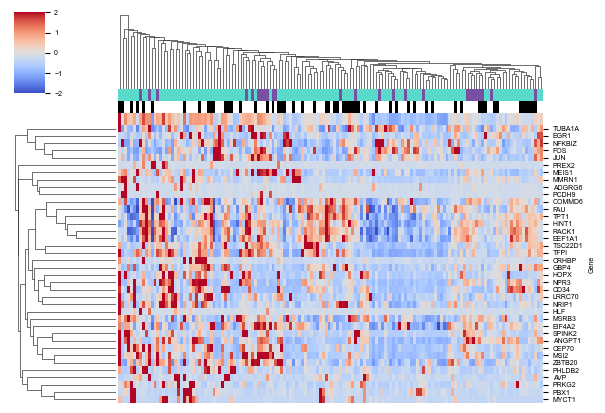

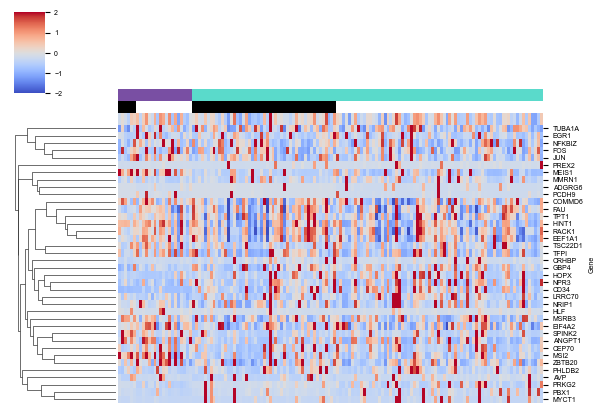

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_gmp
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


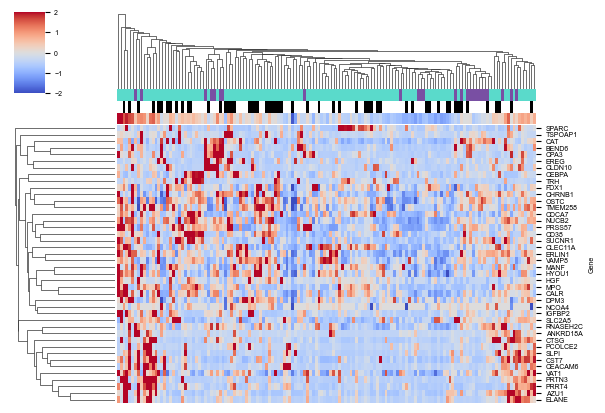

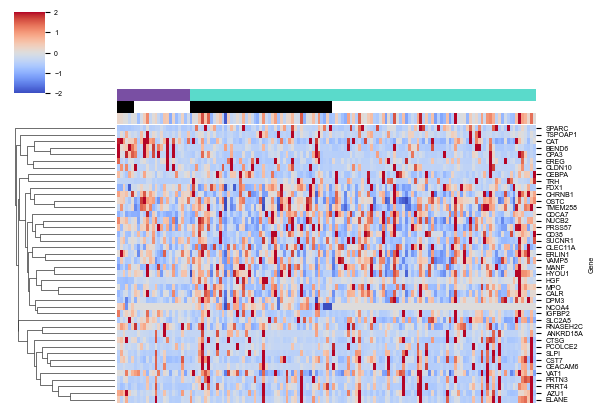

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_myeloid
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


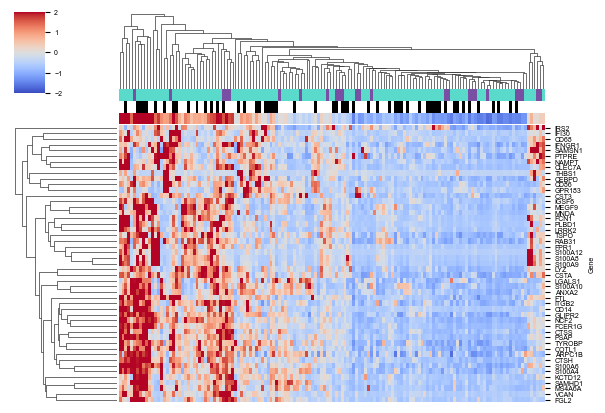

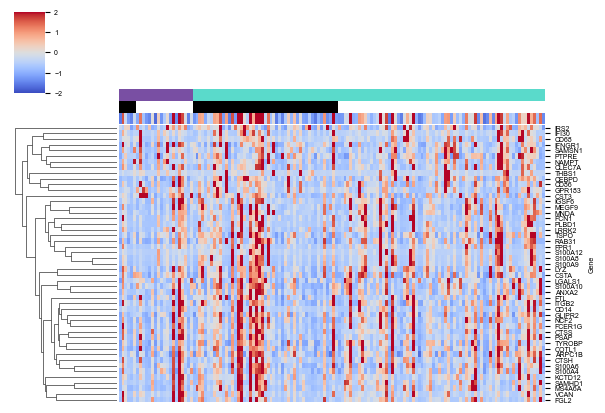

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_hsc_prog_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


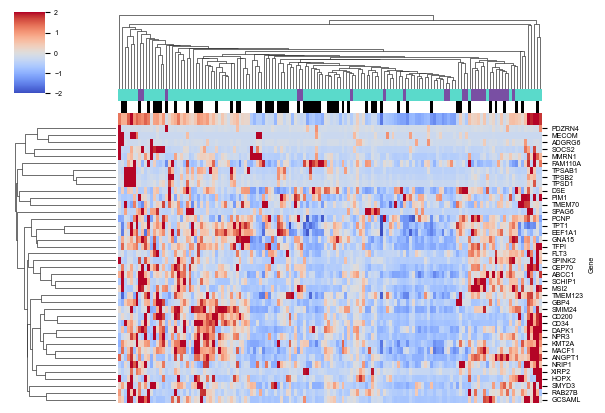

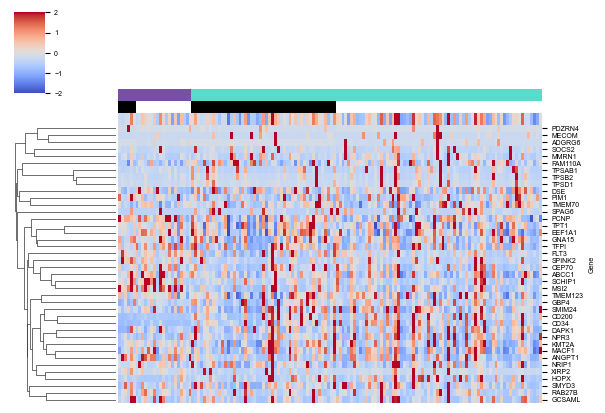

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_gmp_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


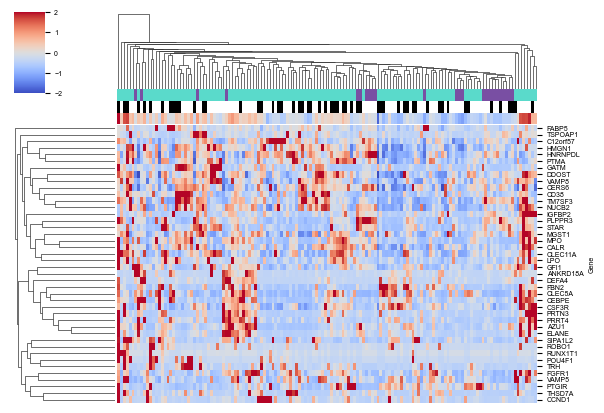

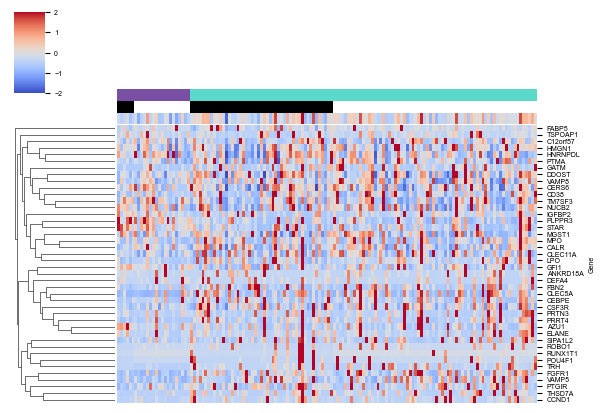

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_myeloid_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


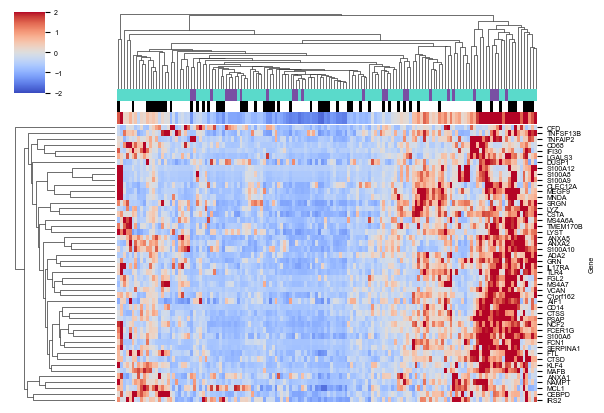

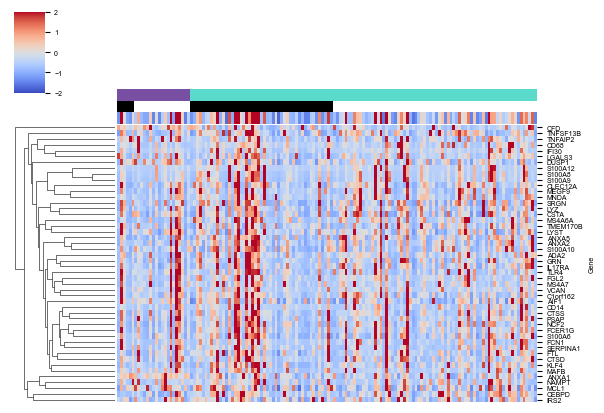

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_hsc_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


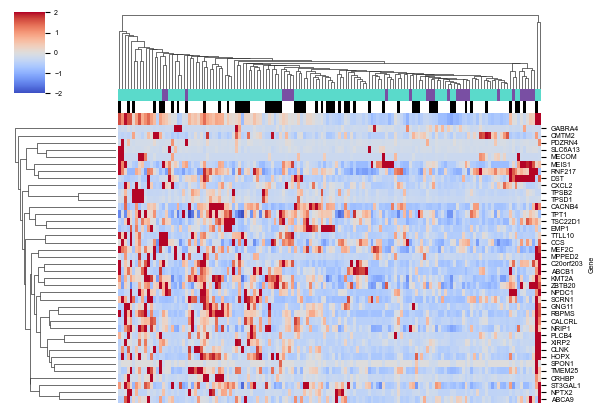

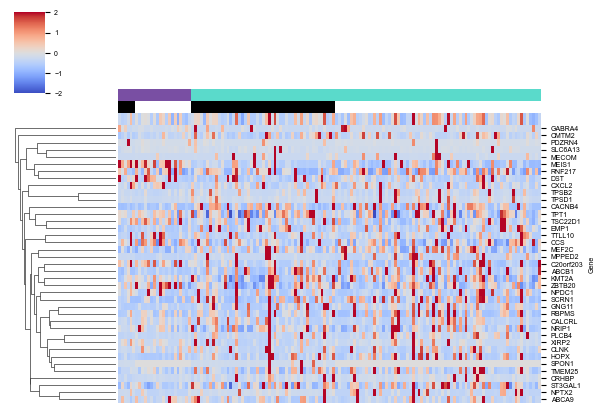

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_prog_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


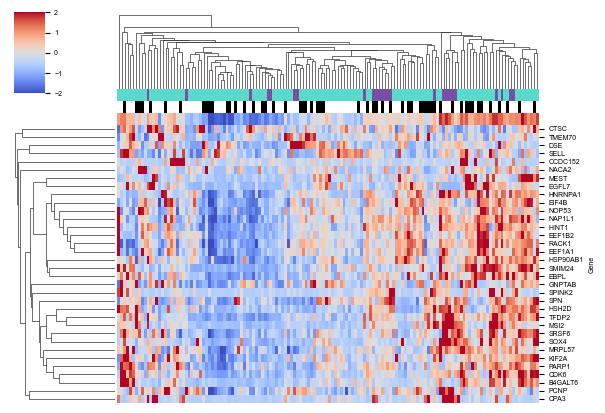

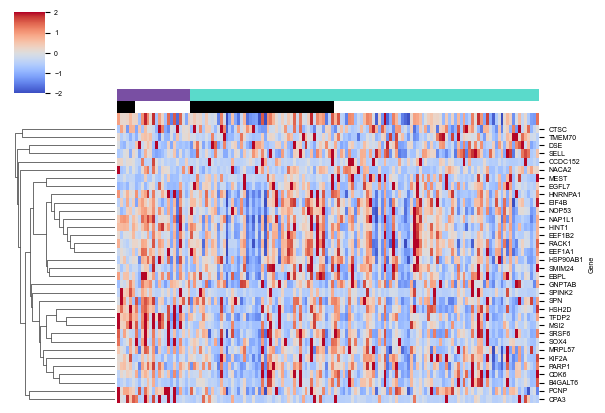

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_promono_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


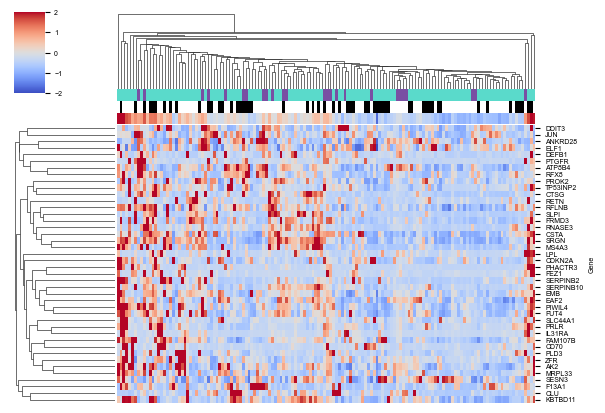

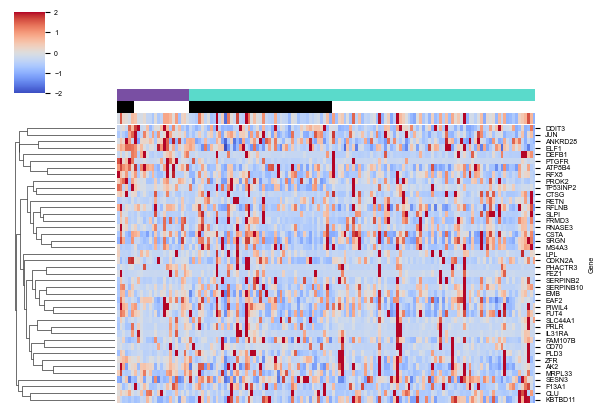

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_mono_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


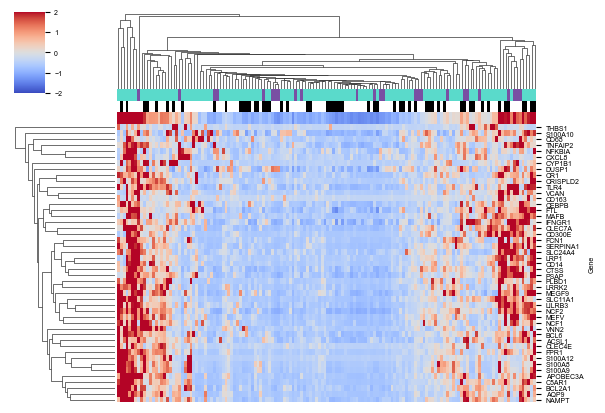

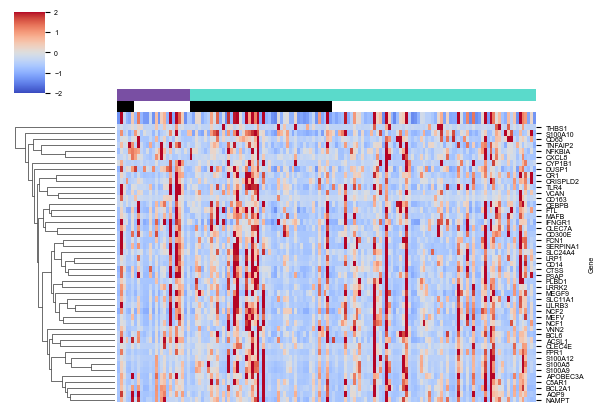

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_cdc_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1784358917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


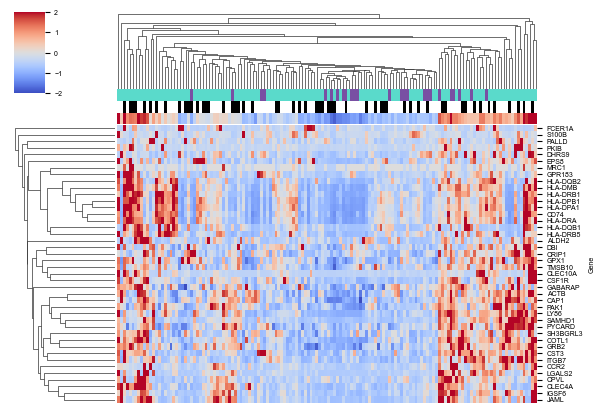

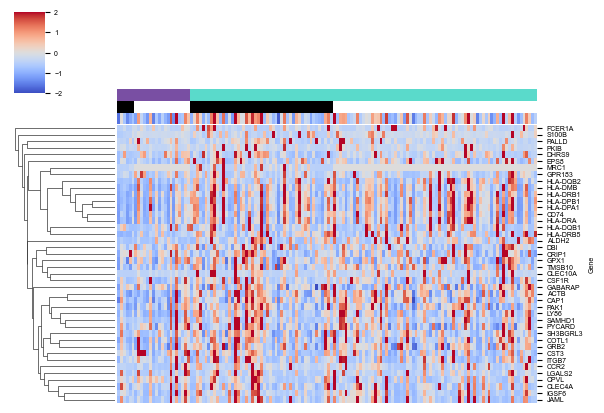

In [63]:
for gs in gene_sets.keys():
    print("=" * 80)
    print(gs)

    df = (
        pl.concat(
            [
                pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
                pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
            ], 
            how="diagonal"
        )
        .filter(pl.col("Block") == "Transcriptomics")
        .drop("Block")
        .rename({"Feature": "Gene"})
        .filter(
            pl.col("Gene").is_in(gene_sets[gs])
        )
        .unpivot(
                index="Gene",
                variable_name="Sample",
                value_name="Z-score"
            )
            .with_columns(
                (
                    pl.col("Sample")
                    .replace(
                        {
                            k: "WT"
                            for k in w_wt_cols + b_wt_cols
                        } | {
                            k: "NPM1"
                            for k in w_mut_cols + b_mut_cols
                        }
                    )
                    .alias("Mutation")
                ),
                (
                    pl.col("Sample")
                    .replace(
                        {
                            k: "black"
                            for k in b_wt_cols + b_mut_cols
                        } | {
                            k: "white"
                            for k in w_wt_cols + w_mut_cols
                        }
                    )
                    .alias("Race")
                )
            )
    )

    df_pan = (
        df
        .filter(pl.col("Z-score").is_not_null())
        .sort("Mutation", "Race")
        .drop("Mutation", "Race")
        .pivot(
            on=["Sample"],
            values="Z-score",
            aggregate_function="mean",
        )
        .fill_null(0)
        .fill_nan(0)
        .to_pandas()
        .set_index("Gene")
    )

    col_colors = [
        ["#5ADACB" if c in b_wt_cols + w_wt_cols else "#794FA3" for c in df_pan.columns],
        ["#000000" if c in b_wt_cols + b_mut_cols else "#FFFFFF" for c in df_pan.columns],
        [v2c(m) for m in df_pan.mean()]
    ]

    for col_cluster in [True, False]:
        cg = sns.clustermap(
            df_pan,
            cmap="coolwarm",
            figsize=(6, 4.5),
            vmin=-2, 
            vmax=2,
            col_cluster=col_cluster,
            col_colors=col_colors,
            yticklabels=True
        )
        cg.ax_heatmap.set_xticks([])
        plt.savefig(
            os.path.join(FIGURE_DIR, f"{gs}_{'col-cluster' if col_cluster else ''}_heatmap.pdf"),
            dpi=400,
            bbox_inches="tight",
            transparent=True
        )
        plt.show()
        plt.close()

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_hsc_prog
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


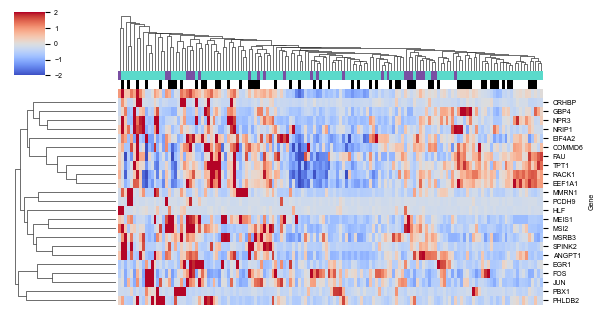

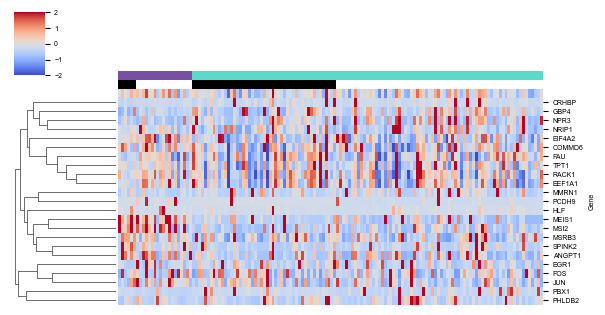

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_gmp
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


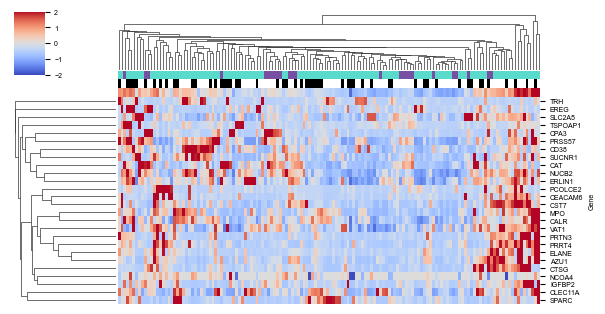

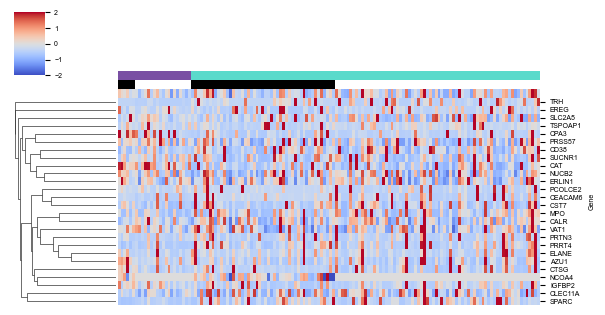

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



normal_myeloid
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


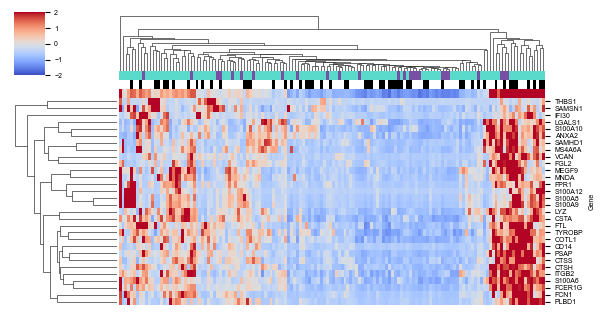

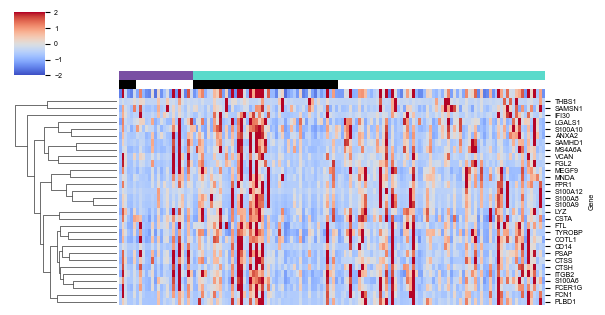

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_hsc_prog_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


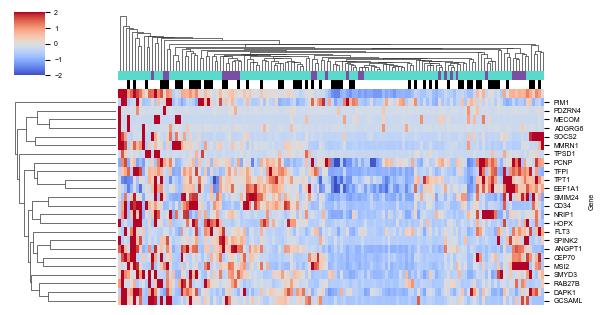

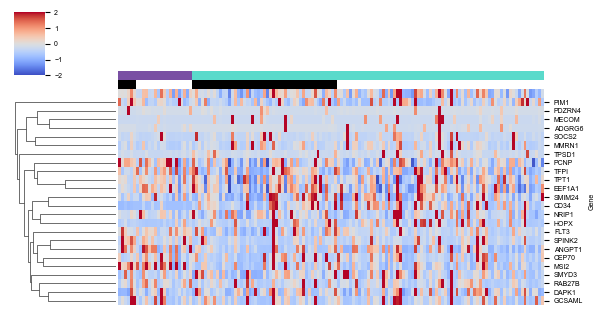

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_gmp_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


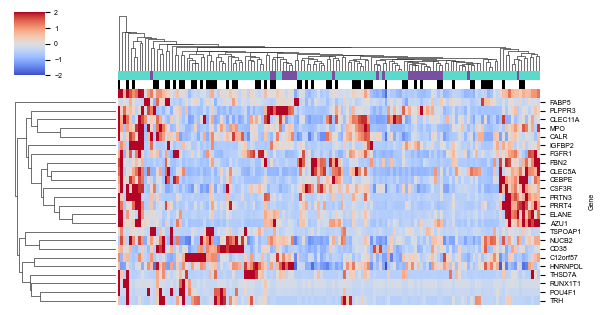

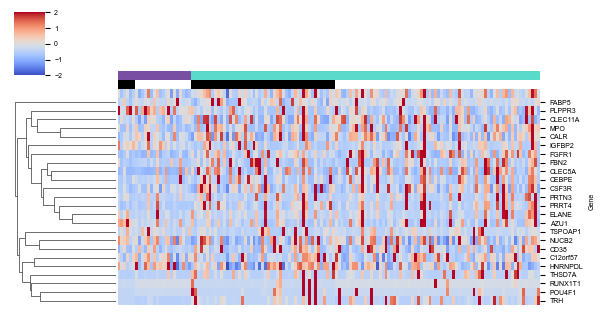

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_myeloid_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


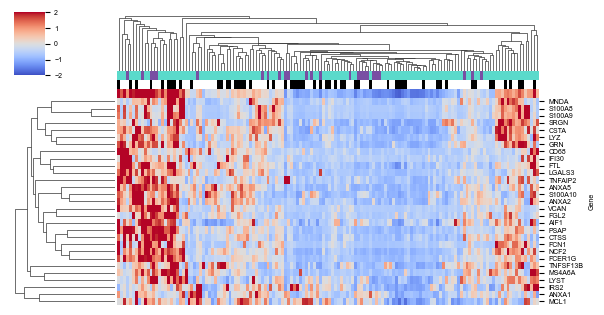

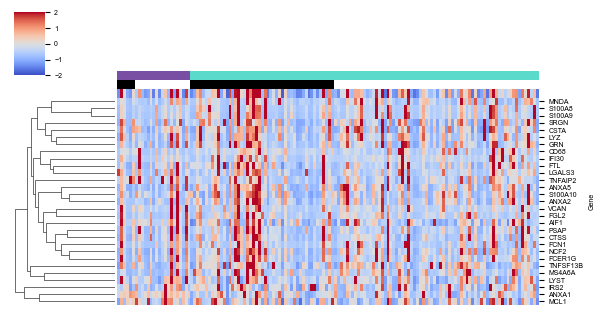

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_hsc_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


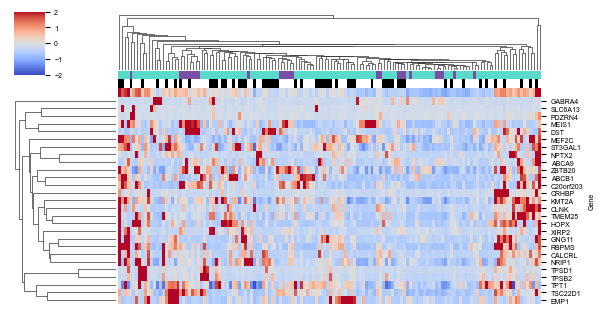

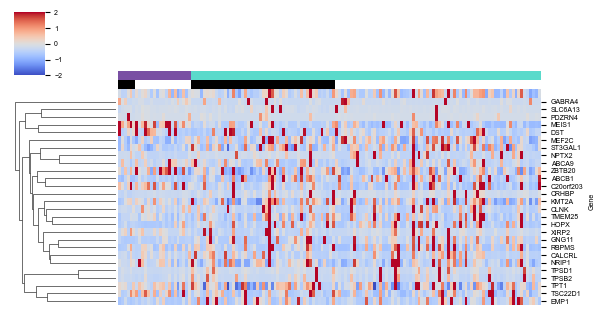

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_prog_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


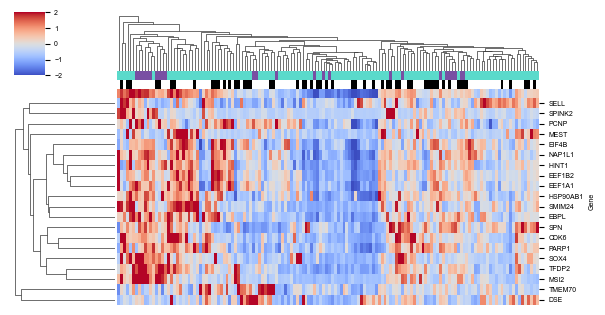

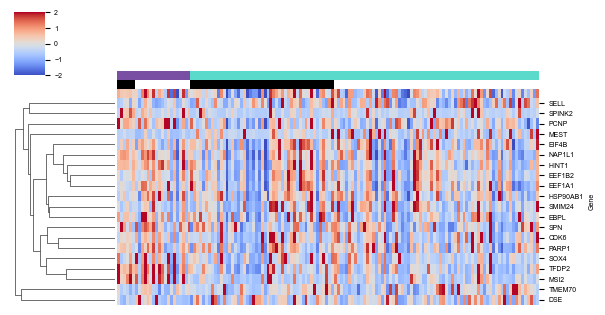

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_promono_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


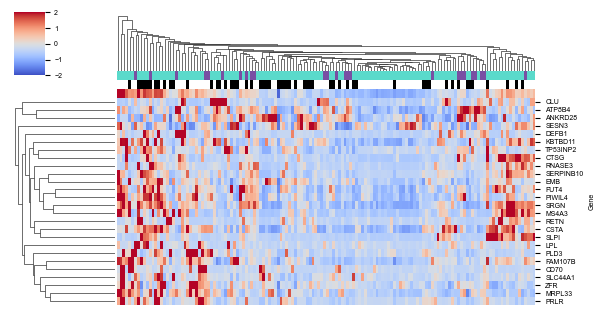

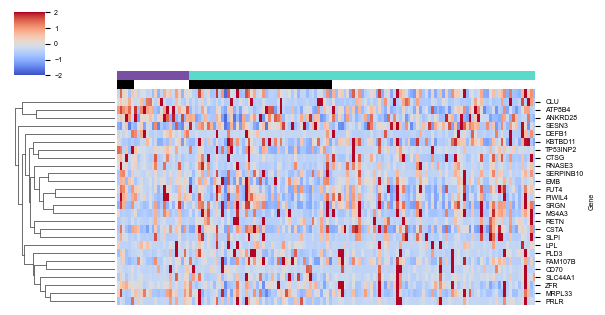

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_mono_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


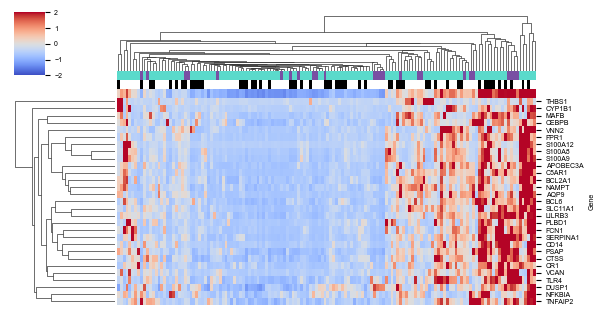

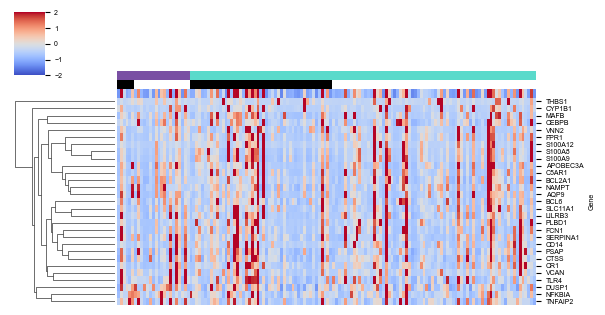

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:8: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),



tumor_cdc_like
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_48212/1566385917.py:9: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)



[syn74776666:W_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/793/174033793/W_NPM1-WT.arrow, skipping download.


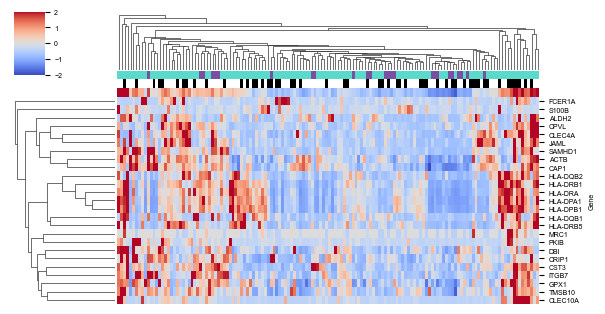

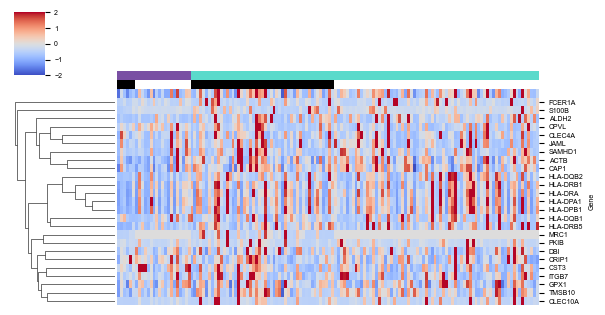

In [64]:
for gs in gene_sets.keys():
    print("=" * 80)
    print(gs)

    df = (
        pl.concat(
            [
                pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["B_NPM1-WT.arrow"]).path),
                pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS["W_NPM1-WT.arrow"]).path)
            ], 
            how="diagonal"
        )
        .filter(pl.col("Block") == "Transcriptomics")
        .drop("Block")
        .rename({"Feature": "Gene"})
        .filter(
            pl.col("Gene").is_in(gene_sets[gs][:30])
        )
        .unpivot(
                index="Gene",
                variable_name="Sample",
                value_name="Z-score"
            )
            .with_columns(
                (
                    pl.col("Sample")
                    .replace(
                        {
                            k: "WT"
                            for k in w_wt_cols + b_wt_cols
                        } | {
                            k: "NPM1"
                            for k in w_mut_cols + b_mut_cols
                        }
                    )
                    .alias("Mutation")
                ),
                (
                    pl.col("Sample")
                    .replace(
                        {
                            k: "black"
                            for k in b_wt_cols + b_mut_cols
                        } | {
                            k: "white"
                            for k in w_wt_cols + w_mut_cols
                        }
                    )
                    .alias("Race")
                )
            )
    )

    df_pan = (
        df
        .filter(pl.col("Z-score").is_not_null())
        .sort("Mutation", "Race")
        .drop("Mutation", "Race")
        .pivot(
            on=["Sample"],
            values="Z-score",
            aggregate_function="mean",
        )
        .fill_null(0)
        .fill_nan(0)
        .to_pandas()
        .set_index("Gene")
    )

    col_colors = [
        ["#5ADACB" if c in b_wt_cols + w_wt_cols else "#794FA3" for c in df_pan.columns],
        ["#000000" if c in b_wt_cols + b_mut_cols else "#FFFFFF" for c in df_pan.columns],
        [v2c(m) for m in df_pan.mean()]
    ]

    for col_cluster in [True, False]:
        cg = sns.clustermap(
            df_pan,
            cmap="coolwarm",
            figsize=(6, 3.5),
            vmin=-2, 
            vmax=2,
            col_cluster=col_cluster,
            col_colors=col_colors,
            yticklabels=True
        )
        cg.ax_heatmap.set_xticks([])
        plt.savefig(
            os.path.join(FIGURE_DIR, f"{gs}_{'col-cluster' if col_cluster else ''}_top30_heatmap.pdf"),
            dpi=400,
            bbox_inches="tight",
            transparent=True
        )
        plt.show()
        plt.close()